# Example 8: Distributed ISL ODTS with a Rotating Lunar Surface Station

This tutorial studies **distributed** onboard orbit determination and time synchronization (ODTS) for a lunar relay constellation, and contrasts it with a **centralized** ground-based filter. The simulated constellation is NASA's five-satellite LCRNS Reference Constellation 3.1 in Elliptical Lunar Frozen Orbits (ELFOs).

Every satellite runs its **own** Schmidt EKF in parallel (five filters). Each estimates its own 8-state `[position, velocity, clock bias, clock drift]` and carries the other four satellites as *consider* states — propagated and used in the measurement update, but never directly corrected.

The measurement architecture has two link types:

- **Satellite ↔ Satellite: a dedicated two-way link.** It provides two-way **range** and **range-rate** (Doppler) — nearly clock-free, so it constrains relative geometry — plus two-way **time transfer** (the clock-bias difference `C·(b_i − b_j)`) and two-way **frequency transfer** (the clock-drift difference `C·(d_i − d_j)`). The transfers make the constellation's *relative* clocks and drifts observable across the crosslink mesh (Section 9).
- **Surface station ↔ Satellite: a one-way pseudorange each way (beacon-like).** A small network of ground stations, each a beacon, exchanges a one-way pseudorange — and its Doppler — with every satellite above its elevation mask. The satellite-side measurements give the onboard filters the one *absolute* time reference the clock-free crosslinks lack; the station-side measurements feed a **centralized ground filter** that estimates the whole constellation from ground tracking alone (Section 10).

The five distributed filters are also **coupled**: every 10 minutes each satellite broadcasts its posterior self-estimate (mean **and** covariance), and every other filter fuses it into the matching consider block. Sections 7–8 show why the naive fusion is over-optimistic and fix it with Covariance Intersection.

The scenario is built from **physical agents** (`configs/isl_odts_distributed.yaml`, driven by `pnt.Simulation`): each satellite is a self-propagating `Spacecraft` whose onboard `SatelliteOdtsApp` runs its Schmidt EKF — generating its own crosslinks and station aiding, and exchanging consider-state with its neighbors — while each ground station is a physical `SurfaceStation` whose `StationBeaconSensor` feeds a `SurfaceStationManager`'s `GroundOdtsApp`, the centralized ground filter. Because an onboard app is *flight software* that never sees truth, the heavy multi-variant run lives in a standalone script, `ex8_run_isl_odts.py`; this notebook just reads the per-satellite estimates it exports.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go

import os, sys
from pathlib import Path

# Use THIS repo's pylupnt/data, not a stale copy on a global PYTHONPATH (~/.zshrc) or kernelspec.
for _b in [Path.cwd(), *Path.cwd().parents]:
    if (_b / "python/pylupnt/__init__.py").exists():
        sys.path.insert(0, str((_b / "python").resolve()))
        if (_b / "data/LuPNT_data/ephemeris").is_dir():
            os.environ["LUPNT_DATA_PATH"] = str((_b / "data/LuPNT_data").resolve())
        break
import pylupnt as pnt

np.random.seed(0)

# Host heavy interactive figures on lupnt-doc-assets instead of embedding them.
import sys as _sys
from pathlib import Path as _Path

for _p in [_Path.cwd(), *_Path.cwd().parents]:
    if (_p / "python" / "examples" / "_doc_assets.py").exists():
        _sys.path.insert(0, str(_p / "python" / "examples"))
        break
from _doc_assets import embed_plotly, embed_cesium_scene

[00.00][PyLuPNT] Initializing


## 1. LCRNS Reference Constellation -- all five satellites

The LCRNS reference document provides five ELFO satellite states at the reference
epoch **2027-03-01 00:00:00.000 UTC**, in the Moon-centered ICRF (Table 2 of the
reference). `SV-1` and `SV-2` share one orbit plane (~180&deg; apart in true anomaly);
`SV-3` and `SV-4` share a second plane; `SV-5` occupies a third. We use these Cartesian
states directly (so no Keplerian-element/frame-convention assumptions are needed) as
the truth trajectories for all five satellites. The constellation is **fully
cross-linked** -- every satellite ranges to every other -- and each runs its own onboard
filter. The orbit period is approximately 30 hours for all five.

In [2]:
t0_str = "2027-03-01T00:00:00"  # UTC, LCRNS Reference Constellation 3.1 epoch

# NASA LCRNS Reference Constellation 3.1 (Ryden & Volle, NASA GSFC), Table 2:
# Cartesian initial states in the Moon-centered ICRF, [km], [km/s]. These are the truth
# initial conditions carried by the five `Spacecraft` agents in isl_odts_distributed.yaml.
lcrns_states_km = {
    "SV-1": ([-198.931445, 386.023132, 3458.355412], [-1.539867, 0.022243, -0.091059]),
    "SV-2": (
        [1089.980598, -2260.918271, -18984.562823],
        [0.280301, -0.004049, 0.016575],
    ),
    "SV-3": ([9187.665852, -260.470721, -8543.222759], [0.273629, 0.417588, -0.313828]),
    "SV-4": (
        [6484.019002, 14329.883921, -7966.345594],
        [-0.258433, 0.033951, 0.235264],
    ),
    "SV-5": (
        [-5074.242314, 14473.022751, -8638.530033],
        [-0.229931, -0.026926, -0.264381],
    ),
}

# LCRNS clock offsets are not specified in the reference document; the config assigns small,
# distinct representative offsets so the crosslinks are not perfectly clock-synced.
for name, (r_km, v_kmps) in lcrns_states_km.items():
    print(f"{name}: |r0| = {np.linalg.norm(r_km):8.1f} km")

a_m = 11316.94e3  # SMA from Table 1 (SV-1), used only to report the orbit period
period_h = 2 * np.pi * np.sqrt(a_m**3 / pnt.GM_MOON) / 3600.0
n_sat_cfg = len(lcrns_states_km)
print(
    f"\nELFO period ~ {period_h:.1f} h; {n_sat_cfg} satellites, "
    f"{n_sat_cfg - 1} crosslinks each, {n_sat_cfg} parallel onboard filters"
)

SV-1: |r0| =   3485.5 km
SV-2: |r0| =  19149.8 km
SV-3: |r0| =  12548.6 km
SV-4: |r0| =  17631.0 km
SV-5: |r0| =  17602.3 km

ELFO period ~ 30.0 h; 5 satellites, 4 crosslinks each, 5 parallel onboard filters


## 2. Distributed ODTS Configuration

The scenario is defined declaratively in `configs/isl_odts_distributed.yaml` and instantiated
by `pnt.Simulation`. It follows the library's **world / physical-agent** pattern:

- A top-level `world:` block holds the shared environment — the frame and the **truth** force
  model (a higher-fidelity lunar gravity field plus Earth/Sun third-body and relativity). Every
  agent inherits it unless it overrides `dynamics:` locally.
- Each satellite is a physical `Spacecraft` agent: it self-propagates its own orbit+clock
  **truth**, and hosts a `SatelliteOdtsApp` — the onboard Schmidt EKF. The app is flight
  software, so it carries only its **filter** force model (a reduced-order gravity field, STM via
  autodiff) and the estimator tunings; it never reads truth directly.
- Each ground station is a physical `SurfaceStation` hosting a `StationBeaconSensor`; a
  non-physical `SurfaceStationManager` hosts the centralized `GroundOdtsApp`.

Note the tuning of the two prior uncertainties: each satellite knows its **own**
just-initialized state to ~200 m, but has only a **coarse broadcast ephemeris** of its
neighbors, ~500 m. That gap is exactly what the 10-minute inter-agent state exchange closes: as
the parallel filters converge, each neighbor's shared self-estimate becomes a far better prior
than the static broadcast. The cell below reads the YAML and summarizes the agent roster.

In [3]:
import yaml
from collections import Counter

_cfg_path = None
for _b in [Path.cwd(), *Path.cwd().parents]:
    if (_b / "configs/isl_odts_distributed.yaml").exists():
        _cfg_path = _b / "configs/isl_odts_distributed.yaml"
        break
scenario = yaml.safe_load(open(_cfg_path))

print(f"scenario : {scenario['name']}")
print(f"epoch    : {scenario['epoch']}   duration: {scenario['duration']}")
print(
    f"world    : frame={scenario['world']['frame']}, "
    f"truth force model = {list(scenario['world']['force_model'].keys())}"
)

roles = Counter(
    (a.get("class"), (a.get("application") or {}).get("class"))
    for a in scenario["agents"].values()
)
print("\nagent roster:")
for (cls, app), n in roles.items():
    print(f"  {n} x {cls:22} hosting {app}")

# One representative onboard SatelliteOdtsApp: filter force model + estimator tunings only
# (no truth-dynamics keys -- the truth force model lives in world:, and each Spacecraft
# self-propagates it).
_sat_app = next(
    a["application"]
    for a in scenario["agents"].values()
    if (a.get("application") or {}).get("class") == "SatelliteOdtsApp"
)
print("\nonboard SatelliteOdtsApp (flight software) key settings:")
_moon = next(b["MOON"] for b in _sat_app["force_model"]["bodies"] if "MOON" in b)
print(f"  filter gravity      : {_moon['n']}x{_moon['m']}  (reduced order)")
print(f"  measurement interval: {_sat_app['dt_s']:.0f} s")
print(
    f"  range / range-rate sigma : {_sat_app['range_sigma_m']} m / "
    f"{_sat_app['range_rate_sigma_mps']} m/s"
)
print(
    f"  time / freq transfer     : {_sat_app['enable_two_way_time_transfer']} / "
    f"{_sat_app['enable_two_way_frequency_transfer']}"
)
print(
    f"  own vs consider prior 1sig: {_sat_app['initial_position_sigma_m']:.0f} m vs "
    f"{_sat_app['consider_position_sigma_m']:.0f} m"
)
print(
    f"  consider exchange interval: {_sat_app['consider_exchange_interval_s'] / 60:.0f} min "
    f"(CI={_sat_app['exchange_use_covariance_intersection']})"
)

scenario : isl_odts_distributed
epoch    : 2027-03-01T00:00:00   duration: 06:00:00
world    : frame=MOON_CI, truth force model = ['integrator', 'dt', 'max_iter', 'abstol', 'reltol', 'autodiff', 'bodies']

agent roster:
  5 x Spacecraft             hosting SatelliteOdtsApp
  1 x SurfaceStationManager  hosting GroundOdtsApp
  3 x SurfaceStation         hosting StationBeaconSensor

onboard SatelliteOdtsApp (flight software) key settings:
  filter gravity      : 8x8  (reduced order)
  measurement interval: 60 s
  range / range-rate sigma : 1.0 m / 0.001 m/s
  time / freq transfer     : True / True
  own vs consider prior 1sig: 200 m vs 500 m
  consider exchange interval: 10 min (CI=False)


In [4]:
# Load the variants produced by ex8_run_isl_odts.py (auto-run below if missing). Each satellite
# is a physical `Spacecraft` agent running a `SatelliteOdtsApp` onboard Schmidt-EKF; each surface
# station is a physical `SurfaceStation` running a `StationBeaconSensor` that feeds a
# `SurfaceStationManager`'s `GroundOdtsApp` (the centralized ground filter, no ISL). The five
# onboard filters + ground filter over the 6 h arc are compute-heavy, so they run in a standalone
# script (agent-based `pnt.Simulation`, configs/isl_odts_distributed.yaml) and this notebook just
# reads the exported estimation results. All variants share the same truth/geometry:
#   res       : full system  (station beacon network + 10-min inter-agent consider-state exchange)
#   res_noex  : exchange OFF  (each filter keeps its static consider states)
#   res_nost  : stations OFF  (crosslinks + exchange only, no absolute timing anchor)
#   res_ci    : Covariance-Intersection exchange (consistent fusion) + matched process noise
import subprocess

_ex_dir = None
for _b in [Path.cwd(), *Path.cwd().parents]:
    if (_b / "python/examples/ex8_run_isl_odts.py").exists():
        _ex_dir = _b / "python/examples"
        break
_data_dir = _ex_dir.parent.parent / "output" / "python_examples" / "ex8_data"
if not (_data_dir / "results_full.npz").exists():
    print("Running ex8_run_isl_odts.py (first run; a few minutes)...")
    subprocess.run([sys.executable, str(_ex_dir / "ex8_run_isl_odts.py")], check=True)

import json as _json

_meta = _json.load(open(_data_dir / "meta.json"))


class _Res:
    """Lightweight view over an ex8_run_isl_odts.py .npz (physical-agent distributed ISL).

    Fields exported per variant: t_s [N]; per-satellite truth_states / own_est [n_sat, N, 8] and
    own_cov_full [n_sat, N, 64]; and the centralized ground filter est_central [N, 8*n_sat] /
    cov_central_full [n_sat, N, 64] (absent in the `nost` variant, which has no ground manager).
    """

    _LIST = {"truth_states", "own_est", "own_cov_full", "cov_central_full"}

    def __init__(self, npz_path, names):
        self._d = dict(np.load(npz_path))
        self.satellite_names = list(names)

    def __getattr__(self, k):
        d = object.__getattribute__(self, "_d")
        if k in _Res._LIST:
            return [d[k][i] for i in range(d[k].shape[0])]
        if k in d:
            return d[k]
        raise AttributeError(k)


res = _Res(_data_dir / "results_full.npz", _meta["satellite_names"])
res_noex = _Res(_data_dir / "results_noex.npz", _meta["satellite_names"])
res_nost = _Res(_data_dir / "results_nost.npz", _meta["satellite_names"])
res_ci = _Res(_data_dir / "results_ci.npz", _meta["satellite_names"])

t_h = res.t_s / 3600.0
n_sat = len(res.satellite_names)
sat_names = res.satellite_names
# NOTE: pylupnt's pnt.C is the speed of light in m/s
C_MPS = pnt.C  # [m/s]
dt_s = float(res.t_s[1] - res.t_s[0]) if len(res.t_s) > 1 else 60.0
print(
    f"Ran {len(t_h)} epochs over {t_h[-1]:.2f} h ({dt_s:.0f} s interval), "
    f"{n_sat} onboard filters + 1 centralized ground filter"
)


def own_block(r, j):
    """Filter j's own 8-state [r, v, clock_bias, clock_drift] estimate over time ([N, 8]).

    The distributed onboard app publishes only its own posterior block (not the coordinator's
    global stacked state), so this is the estimate directly, epoch-aligned with truth_states[j].
    """
    return r.own_est[j]


def own_cov_8x8(r, j):
    """Filter j's own 8x8 posterior covariance time series ([N, 8, 8])."""
    return np.asarray(r.own_cov_full[j]).reshape(len(r.t_s), 8, 8)


def own_cov_diag(r, j):
    """Diagonal of filter j's own posterior covariance ([N, 8])."""
    return np.diagonal(own_cov_8x8(r, j), axis1=1, axis2=2)


def final_pos_err(r, j):
    return np.linalg.norm(r.truth_states[j][-1, :3] - own_block(r, j)[-1, :3])


def final_clk_err_m(r, j):
    return abs(r.truth_states[j][-1, 6] - own_block(r, j)[-1, 6]) * C_MPS


print("\nFinal own-state error per satellite (distributed ISL filter):")
print(
    f"{'sat':>6} | {'pos [m] full':>13} {'no-exch':>9} {'no-stn':>9} | {'clk [m] full':>13} {'no-stn':>9}"
)
for j in range(n_sat):
    print(
        f"{sat_names[j]:>6} | {final_pos_err(res, j):13.1f} {final_pos_err(res_noex, j):9.1f} "
        f"{final_pos_err(res_nost, j):9.1f} | {final_clk_err_m(res, j):13.1f} "
        f"{final_clk_err_m(res_nost, j):9.1f}"
    )
mean = lambda f, r: np.mean([f(r, j) for j in range(n_sat)])
print(
    f"\nmean position: full {mean(final_pos_err, res):.0f} m | "
    f"no-exchange {mean(final_pos_err, res_noex):.0f} m  (exchange fixes the orbit)"
)
print(
    f"mean clock   : full {mean(final_clk_err_m, res):.0f} m | "
    f"no-station {mean(final_clk_err_m, res_nost):.0f} m  (station fixes the timing)"
)

Ran 361 epochs over 6.00 h (60 s interval), 5 onboard filters + 1 centralized ground filter

Final own-state error per satellite (distributed ISL filter):
   sat |  pos [m] full   no-exch    no-stn |  clk [m] full    no-stn
  SV-1 |          31.0       9.8     439.0 |          25.5     410.4
  SV-2 |          25.4      36.1     316.5 |          24.3     410.1
  SV-3 |          39.0     444.1     223.5 |          24.3     410.0
  SV-4 |          55.7     200.6     570.6 |          23.7     410.2
  SV-5 |          53.0     122.6     726.7 |          26.8     410.2

mean position: full 41 m | no-exchange 163 m  (exchange fixes the orbit)
mean clock   : full 25 m | no-station 410 m  (station fixes the timing)


## 3. Plot 1 -- Orbits and the crosslink mesh

The five ELFO trajectories over the simulated arc (the self-propagated `Spacecraft` truth
tracks). The dark-grey segments are the inter-satellite crosslink mesh at a single snapshot
epoch -- every pair is linked. The ELFOs spend most of their long (~30 h) period near apolune
over the southern hemisphere, which is why a south-pole surface station (Section 10) can see
most of the constellation most of the time.

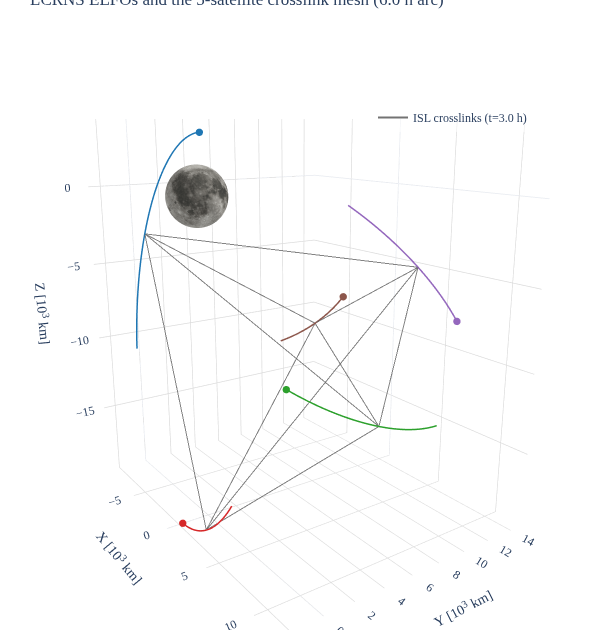

In [5]:
sat_colors = ["#1F77B4", "#D62728", "#2CA02C", "#9467BD", "#8C564B"]

# pnt.plot.plot_orbits / plot_body divide their metre inputs by 10**scale (scale=6),
# i.e. the figure's coordinate space is in units of 10^3 km. Any trace we add by hand
# (crosslinks) must be divided by the SAME factor to line up with the orbits.
SCALE = 1e6

fig = go.Figure()
pnt.plot.plot_body(fig, pnt.MOON)
pnt.plot.plot_orbits(
    fig,
    np.stack([ts[:, :6] for ts in res.truth_states]),
    t=0,
    color=sat_colors,
)

# Inter-satellite crosslinks: the full mesh (every unique pair) at one snapshot epoch.
k_mesh = len(t_h) // 2
shown_isl = False
for a in range(n_sat):
    for b in range(a + 1, n_sat):
        ra = res.truth_states[a][k_mesh, :3] / SCALE
        rb = res.truth_states[b][k_mesh, :3] / SCALE
        fig.add_trace(
            go.Scatter3d(
                x=[ra[0], rb[0]],
                y=[ra[1], rb[1]],
                z=[ra[2], rb[2]],
                mode="lines",
                line=dict(color="rgba(80,80,80,0.8)", width=2),
                name=f"ISL crosslinks (t={t_h[k_mesh]:.1f} h)",
                legendgroup="isl",
                showlegend=not shown_isl,
            )
        )
        shown_isl = True

pnt.plot.set_view(fig, azimuth=-35, elevation=15, zoom=2.2)
fig.update_layout(
    title=f"LCRNS ELFOs and the {n_sat}-satellite crosslink mesh ({t_h[-1]:.1f} h arc)",
    height=700,
    showlegend=True,
)
embed_plotly(fig, "ex8_isl_geometry")

## 4. Plot 2 -- Crosslink range and range-rate geometry

The constellation is fully cross-linked. For a legible plot we show only the four links
referenced to `SV-1`, reconstructed from the exported truth geometry: the two-way **range**
`|r_i − r_j|` and its **range-rate** (the radial relative velocity). These are exactly the
geometric observables the dedicated two-way link measures -- nearly clock-free, so they
constrain relative geometry. The simplified link budget (C/N0) and the per-epoch *noisy*
observations are generated internally by each satellite's onboard crosslink sensor and are not
exported by the flight-software apps, so this plot shows the underlying truth geometry.

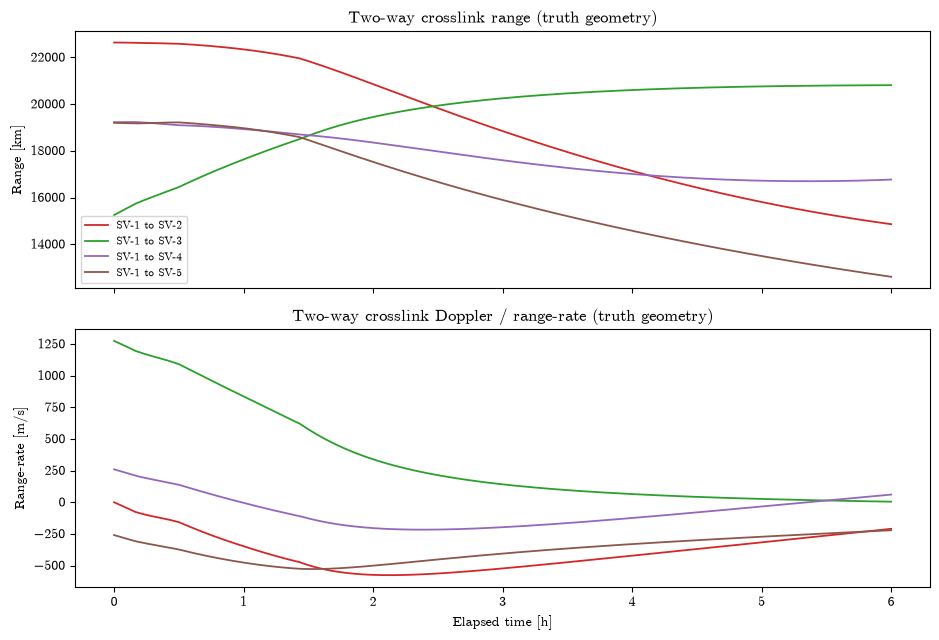

SV-1<->SV-2 range spans 14859 - 22635 km over the 6.0 h arc (the crosslink geometry the onboard filters range across).


In [6]:
# Reconstruct the SV-1-referenced crosslink geometry from the exported truth states.
link_names = sat_names[1:]  # SV-1 -> SV-{2..5}
link_colors = sat_colors[1:]


def crosslink_range_rate(a, b):
    """Two-way range [m] and range-rate [m/s] between satellites a and b from truth geometry."""
    dr = res.truth_states[b][:, :3] - res.truth_states[a][:, :3]
    dv = res.truth_states[b][:, 3:6] - res.truth_states[a][:, 3:6]
    rng = np.linalg.norm(dr, axis=1)
    rate = np.sum(dr * dv, axis=1) / rng
    return rng, rate


fig, axes = plt.subplots(2, 1, figsize=(9.5, 6.5), sharex=True)
for i, name in enumerate(link_names):
    rng, rate = crosslink_range_rate(0, i + 1)
    axes[0].plot(
        t_h, rng / 1e3, color=link_colors[i], lw=1.3, label=f"{sat_names[0]} to {name}"
    )
    axes[1].plot(
        t_h, rate, color=link_colors[i], lw=1.3, label=f"{sat_names[0]} to {name}"
    )

axes[0].set_ylabel("Range [km]")
axes[0].set_title("Two-way crosslink range (truth geometry)")
axes[0].legend(loc="best", fontsize=8)
axes[1].set_ylabel("Range-rate [m/s]")
axes[1].set_xlabel("Elapsed time [h]")
axes[1].set_title("Two-way crosslink Doppler / range-rate (truth geometry)")
plt.tight_layout()
plt.show()

rng0, _ = crosslink_range_rate(0, 1)
print(
    f"{sat_names[0]}<->{link_names[0]} range spans "
    f"{rng0.min() / 1e3:.0f} - {rng0.max() / 1e3:.0f} km over the {t_h[-1]:.1f} h arc "
    f"(the crosslink geometry the onboard filters range across)."
)

## 5. Distributed ODTS convergence -- all five filters

Each satellite's own filter is compared against the truth and its formal 3-sigma
covariance envelope. The top row shows every satellite's own position and clock-bias
error under the full system. The bottom row isolates the two observability
contributions across the constellation mean:

- **Orbit** comes from the crosslinks *and the inter-agent exchange*. Two-way ranging
  only fixes geometry relative to neighbors whose states are known; sharing each
  filter's converged self-estimate every 10 minutes is what turns coarse neighbor
  priors into tight ones, so the position error collapses (compare *no-exchange*).
- **Timing** comes from the surface station. Two-way crosslinks cancel clock bias to
  first order, so without the station the clocks drift essentially unobserved (compare
  *no-station*); the rotating one-way pseudorange pins them down.

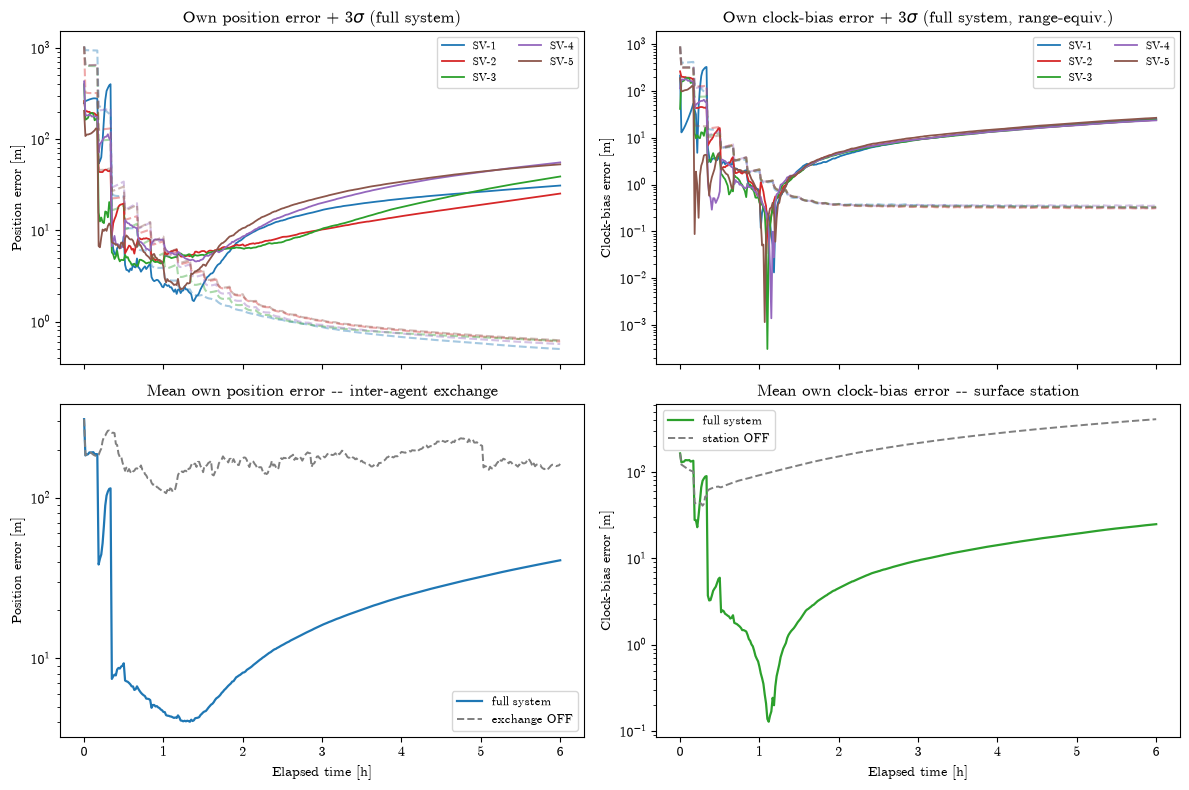

Final constellation-mean own error:
  position : full    40.8 m   |  exchange OFF    162.6 m
  clock    : full   24.91 m   |  station  OFF   410.18 m


In [7]:
def pos_err_ts(r, j):
    return np.linalg.norm(r.truth_states[j][:, :3] - own_block(r, j)[:, :3], axis=1)


def pos_3sig(r, j):
    cd = own_cov_diag(r, j)
    return 3 * np.sqrt(cd[:, 0] + cd[:, 1] + cd[:, 2])


def clk_err_ts(r, j):
    return np.abs(r.truth_states[j][:, 6] - own_block(r, j)[:, 6]) * C_MPS


def clk_3sig(r, j):
    return 3 * np.sqrt(own_cov_diag(r, j)[:, 6]) * C_MPS


mean_pos = lambda r: np.mean([pos_err_ts(r, j) for j in range(n_sat)], axis=0)
mean_clk = lambda r: np.mean([clk_err_ts(r, j) for j in range(n_sat)], axis=0)

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)

# (0,0) per-satellite own position error + 3-sigma (full system)
for j in range(n_sat):
    axes[0, 0].plot(
        t_h, pos_err_ts(res, j), color=sat_colors[j], lw=1.3, label=sat_names[j]
    )
    axes[0, 0].plot(t_h, pos_3sig(res, j), "--", color=sat_colors[j], alpha=0.4)
axes[0, 0].set_yscale("log")
axes[0, 0].set_title("Own position error + 3$\\sigma$ (full system)")
axes[0, 0].set_ylabel("Position error [m]")
axes[0, 0].legend(loc="best", fontsize=8, ncol=2)

# (0,1) per-satellite own clock-bias error + 3-sigma (full system)
for j in range(n_sat):
    axes[0, 1].plot(
        t_h, clk_err_ts(res, j), color=sat_colors[j], lw=1.3, label=sat_names[j]
    )
    axes[0, 1].plot(t_h, clk_3sig(res, j), "--", color=sat_colors[j], alpha=0.4)
axes[0, 1].set_yscale("log")
axes[0, 1].set_title("Own clock-bias error + 3$\\sigma$ (full system, range-equiv.)")
axes[0, 1].set_ylabel("Clock-bias error [m]")
axes[0, 1].legend(loc="best", fontsize=8, ncol=2)

# (1,0) constellation-mean position: exchange drives the orbit
axes[1, 0].plot(t_h, mean_pos(res), color="#1F77B4", lw=1.6, label="full system")
axes[1, 0].plot(
    t_h, mean_pos(res_noex), color="#7F7F7F", lw=1.4, ls="--", label="exchange OFF"
)
axes[1, 0].set_yscale("log")
axes[1, 0].set_title("Mean own position error -- inter-agent exchange")
axes[1, 0].set_ylabel("Position error [m]")
axes[1, 0].set_xlabel("Elapsed time [h]")
axes[1, 0].legend(loc="best", fontsize=9)

# (1,1) constellation-mean clock: station drives the timing
axes[1, 1].plot(t_h, mean_clk(res), color="#2CA02C", lw=1.6, label="full system")
axes[1, 1].plot(
    t_h, mean_clk(res_nost), color="#7F7F7F", lw=1.4, ls="--", label="station OFF"
)
axes[1, 1].set_yscale("log")
axes[1, 1].set_title("Mean own clock-bias error -- surface station")
axes[1, 1].set_ylabel("Clock-bias error [m]")
axes[1, 1].set_xlabel("Elapsed time [h]")
axes[1, 1].legend(loc="best", fontsize=9)

plt.tight_layout()
plt.show()

print("Final constellation-mean own error:")
print(
    f"  position : full {mean_pos(res)[-1]:7.1f} m   |  exchange OFF {mean_pos(res_noex)[-1]:8.1f} m"
)
print(
    f"  clock    : full {mean_clk(res)[-1]:7.2f} m   |  station  OFF {mean_clk(res_nost)[-1]:8.2f} m"
)

## 6. Surface-station beacon coverage

Each station is a **beacon**: every epoch it exchanges a one-way pseudorange (and its Doppler)
with every satellite above its elevation mask. That coverage gives the onboard filters their one
*absolute* time reference and feeds the centralized ground filter (Section 10). The low-perilune
`SV-1` dips below the stations' horizons for long stretches, so it is covered least — which is
exactly why it is the hardest satellite for the ground filter.

In the physical-agent design this visibility bookkeeping and the pre-fit pseudorange residuals
are internal state of each `StationBeaconSensor` and each satellite's onboard filter — flight
software that never surfaces truth — so they are not exported to this notebook. Their *net*
effect on the estimate is what Sections 5 (station ON vs OFF) and 8 (covariance consistency)
measure directly.

## 7. Consider-state exchange between the parallel filters

Each satellite carries the others as consider states. Between exchanges a consider block only
grows — it is propagated with process noise and never corrected by that satellite's own
measurements. Every 10 minutes, though, the inter-agent exchange refreshes it from the neighbor's
freshly converged self-estimate (mean **and** covariance), producing a characteristic
**sawtooth**: grow, reset, grow, reset. With the exchange disabled, a neighbor block instead
grows without bound from the coarse 500 m broadcast prior — the neighbor uncertainty that would
otherwise cap the whole constellation's accuracy.

In the distributed physical-agent design each onboard `SatelliteOdtsApp` publishes only its
**own** posterior block; the per-neighbor consider covariances are internal filter state and are
not exported, so the sawtooth itself is not plotted here. Its net effect is exactly the
*exchange ON vs OFF* gap already visible in Section 5, and the next section quantifies whether
the exchanged covariance is *honest*.

> The default exchange here is the **naive-overwrite baseline**
> (`exchange_use_covariance_intersection: false`): each reset simply *adopts* the neighbor's
> self-reported covariance. That makes the sawtooth reset to a very small value — but as the next
> section shows, that small value is not trustworthy, because the two filters being fused are
> correlated. Section 8 quantifies the resulting over-confidence and fixes it with Covariance
> Intersection.

## 8. Is the covariance honest? Consistency and Covariance Intersection

Sections 5-7 tracked *accuracy* (error vs. its formal 3-$\sigma$ envelope). But a
navigation filter also has to report **trustworthy uncertainty** -- a consumer of the
ephemeris (a lander, a rover, an integrity monitor) trusts the covariance, not the
(unknowable) true error. The standard consistency check is **NEES** (Normalized
Estimation Error Squared):

$$\varepsilon_k = (\hat{x}_k - x_k)^\top P_k^{-1} (\hat{x}_k - x_k), \qquad
  \mathbb{E}[\varepsilon_k] = \dim(x)$$

For a *consistent* filter the NEES sits near its number of degrees of freedom (3 for
position, 8 for the full state). $\varepsilon_k \gg \dim$ means $P_k$ is **optimistic**:
the filter claims far more accuracy than it has.

**Why the naive exchange is optimistic.** The five filters are *not* independent -- they
share the same two-way crosslink observations, and every 10-minute exchange has already
mixed their estimates. Overwriting a consider block with a neighbor's posterior (and
zeroing its cross-covariance) treats that broadcast as *fresh, independent* information.
It is not, so the same information gets counted again and again: a **data-incest**
feedback loop. Each filter's consider blocks collapse $\Rightarrow$ the crosslink
innovation covariance $S = R + HPH^\top$ barely inflates $\Rightarrow$ the own covariance
collapses $\Rightarrow$ that over-confident estimate is broadcast $\Rightarrow$ neighbors
collapse further. The reported $\sigma$ ends up *orders of magnitude* below the true error.

**The consistent fix: Covariance Intersection (Julier & Uhlmann).** Fuse each broadcast
into the consider block as a **convex** combination of information,

$$P_b' = \big(w\,P_b^{-1} + (1-w)\,P_{\text{bcast}}^{-1}\big)^{-1}, \qquad
  m_b' = P_b'\big(w\,P_b^{-1} m_b + (1-w)\,P_{\text{bcast}}^{-1} m_{\text{bcast}}\big).$$

Because it is convex (weights sum to 1) rather than additive, CI is **guaranteed
consistent for *any* unknown cross-correlation** between the two estimates and cannot
manufacture confidence -- exactly what breaks the incest loop. It addresses both the
exchange-induced and shared-measurement optimism at once. Enable it with
`cfg.exchange_use_covariance_intersection = True` (and `exchange_ci_weight` to pin $w$,
else it is chosen per block by minimizing the fused-block covariance).

**One caveat -- CI and process noise compose.** CI keeps the *fusion* consistent only if
each filter's own posterior is *itself* consistent. Here the absolute position is weakly
observable (a single round-robin station), so each own covariance is also too tight until
the process noise `process_accel_sigma_mps2` is raised to cover that unmodelled drift.
The two levers are complementary: process noise makes each broadcast honest, CI keeps the
fusion of those honest broadcasts honest. Below we turn on **both** and re-check the NEES.

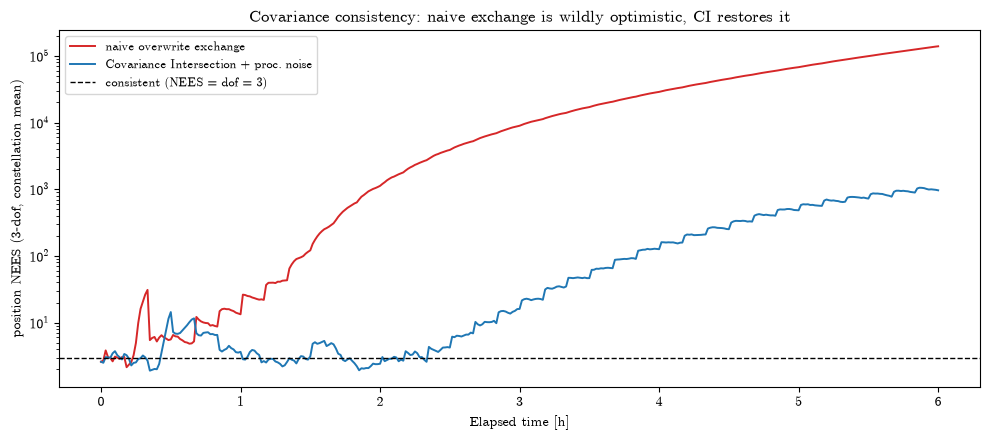

                   pos NEES(3)  pos RMSE [m]  reported sig [m]


naive overwrite        34179.9          24.5              0.42
CI + proc. noise         236.1          19.5             16.25

The naive filter looks a little more accurate but reports a sigma tens of times
below its true error -- its position NEES is ~11,393x the consistent
value of 3. Covariance Intersection + process noise cuts the over-confidence by
~145x (NEES ~236, i.e. a ~8.9x sigma
factor), trading a little accuracy for a covariance the same order as the true error.


In [8]:
# --- NEES helpers (own_cov_8x8 is defined in the setup cell) -------------------------
def nees_ts(r, dof=3):
    """Per-epoch NEES averaged over the constellation.

    dof=3 -> position only, dof=8 -> full [r, v, clock_bias, clock_drift] state.
    A consistent filter sits near `dof`; NEES >> dof means the covariance is optimistic.
    """
    N, ns = len(r.t_s), len(r.satellite_names)
    out = np.full(N, np.nan)
    for k in range(N):
        vals = []
        for j in range(ns):
            e = own_block(r, j)[k, :dof] - r.truth_states[j][k, :dof]
            P = own_cov_8x8(r, j)[k, :dof, :dof]
            vals.append(float(e @ np.linalg.solve(P, e)))
        out[k] = np.mean(vals)
    return out


# --- Consistent variant: Covariance Intersection exchange + matched process noise ----
# `res_ci` is the `ci` variant produced by ex8_run_isl_odts.py (loaded in the setup cell):
# the SAME truth/geometry, but the consider-state exchange uses Covariance Intersection
# (ci_weight 0.95) with a larger process noise to cover the weakly-observable drift.

DOF = 3  # position-only NEES
nees_naive = nees_ts(res, DOF)
nees_ci = nees_ts(res_ci, DOF)
settle = t_h > 1.0  # ignore the initial transient in the summary statistics


def rms_pos(r):
    return np.sqrt(np.mean([pos_err_ts(r, j)[settle] ** 2 for j in range(n_sat)]))


def mean_pos_sigma(r):
    s = [
        np.sqrt(np.trace(own_cov_8x8(r, j)[k, :3, :3]))
        for j in range(n_sat)
        for k in np.where(settle)[0]
    ]
    return np.mean(s)


fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(t_h, nees_naive, color="#D62728", lw=1.4, label="naive overwrite exchange")
ax.plot(
    t_h, nees_ci, color="#1F77B4", lw=1.4, label="Covariance Intersection + proc. noise"
)
ax.axhline(DOF, color="k", lw=1.0, ls="--", label=f"consistent (NEES = dof = {DOF})")
ax.set_yscale("log")
ax.set_ylabel(f"position NEES ({DOF}-dof, constellation mean)")
ax.set_xlabel("Elapsed time [h]")
ax.set_title(
    "Covariance consistency: naive exchange is wildly optimistic, CI restores it"
)
ax.legend(loc="best", fontsize=9)
plt.tight_layout()
plt.show()

print(f"{'':16}{'pos NEES(3)':>14}{'pos RMSE [m]':>14}{'reported sig [m]':>18}")
stats_out = {}
for tag, r in [("naive overwrite", res), ("CI + proc. noise", res_ci)]:
    n = np.nanmean(nees_ts(r, DOF)[settle])
    stats_out[tag] = (n, rms_pos(r), mean_pos_sigma(r))
    print(f"{tag:16}{n:14.1f}{stats_out[tag][1]:14.1f}{stats_out[tag][2]:18.2f}")

n_naive = stats_out["naive overwrite"][0]
n_ci = stats_out["CI + proc. noise"][0]
print(
    f"\nThe naive filter looks a little more accurate but reports a sigma tens of times\n"
    f"below its true error -- its position NEES is ~{n_naive / DOF:,.0f}x the consistent\n"
    f"value of {DOF}. Covariance Intersection + process noise cuts the over-confidence by\n"
    f"~{n_naive / n_ci:,.0f}x (NEES ~{n_ci:.0f}, i.e. a ~{np.sqrt(n_ci / DOF):.1f}x sigma\n"
    f"factor), trading a little accuracy for a covariance the same order as the true error."
)

## 9. Two-way time and frequency transfer on the crosslinks

The dedicated satellite-to-satellite link is more than a ranging channel. Coherent
two-way ranging **cancels** the clocks (its sum-of-one-ways gives geometric range), so by
itself it says nothing about how the satellites' clocks relate. Two extra observables
close that gap, at a cost comparable to the ranging itself:

- **Two-way time transfer** — the *difference* of the two one-way exchanges recovers the
  clock-bias offset $C\,(b_i - b_j)$ between the endpoints.
- **Two-way frequency transfer** — its rate companion, $C\,(d_i - d_j)$, recovers the
  clock-*drift* difference directly (rather than waiting for it to integrate into bias).

Together they make the whole constellation's **relative** clocks and drifts observable
across the crosslink mesh; the surface-station beacons then only have to pin the one
**absolute** time reference. Below we turn the two transfers on in sequence (using the
consistent Covariance-Intersection exchange from Section 8) and watch the constellation
clock-bias and clock-drift errors drop.

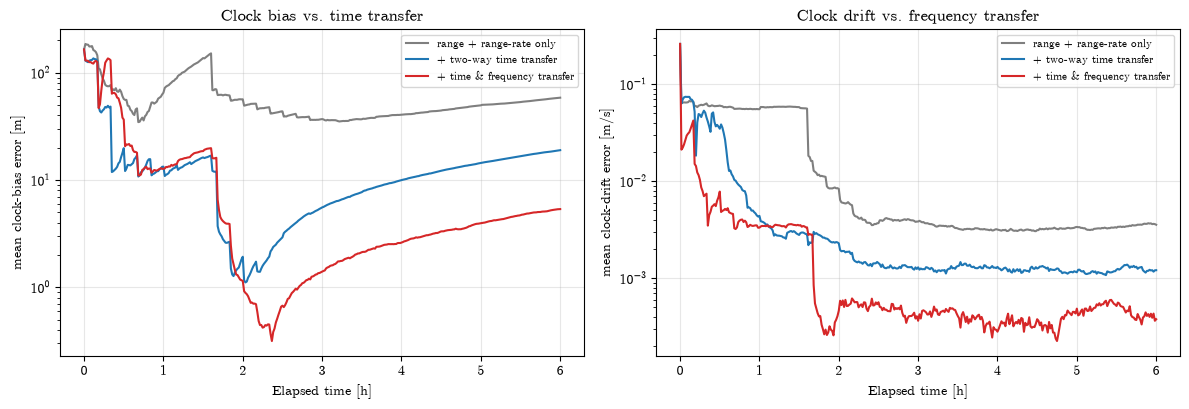

crosslink observables             clk bias [m]  clk drift [m/s]
range + range-rate only                   58.5          0.00356
+ two-way time transfer                   19.0          0.00121
+ time & frequency transfer                5.4          0.00038

Two-way ranging alone leaves the clocks weakly tied; adding time transfer collapses
the clock-bias error, and frequency transfer additionally tightens the clock drift.


In [9]:
# Turn the two crosslink clock observables on in sequence, on the SAME truth/geometry.
# Use the consistent CI exchange (Section 8) so the comparison is not muddied by the
# naive-overwrite data incest.
transfer_variants = [
    ("range + range-rate only", False, False, "#7F7F7F"),
    ("+ two-way time transfer", True, False, "#1F77B4"),
    ("+ time & frequency transfer", True, True, "#D62728"),
]


def clk_err_ts_mean(r):
    return np.mean(
        [
            np.abs(r.truth_states[j][:, 6] - own_block(r, j)[:, 6]) * C_MPS
            for j in range(n_sat)
        ],
        axis=0,
    )


def drift_err_ts_mean(r):
    return np.mean(
        [
            np.abs(r.truth_states[j][:, 7] - own_block(r, j)[:, 7]) * C_MPS
            for j in range(n_sat)
        ],
        axis=0,
    )


# The three sweep variants (CI exchange, weight 0.9) are produced by ex8_run_isl_odts.py
# and loaded here from their .npz, in the same label order as `transfer_variants`.
_tf_tags = ["tf_rr", "tf_tt", "tf_ttft"]
runs_tf = {
    label: _Res(_data_dir / f"results_{tag}.npz", _meta["satellite_names"])
    for (label, _tt, _ft, _c), tag in zip(transfer_variants, _tf_tags)
}

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for label, tt, ft, color in transfer_variants:
    r = runs_tf[label]
    axes[0].plot(t_h, clk_err_ts_mean(r), color=color, lw=1.5, label=label)
    axes[1].plot(t_h, drift_err_ts_mean(r), color=color, lw=1.5, label=label)
axes[0].set_yscale("log")
axes[0].set_ylabel("mean clock-bias error [m]")
axes[0].set_xlabel("Elapsed time [h]")
axes[0].set_title("Clock bias vs. time transfer")
axes[0].legend(loc="best", fontsize=8)
axes[0].grid(True, alpha=0.3)
axes[1].set_yscale("log")
axes[1].set_ylabel("mean clock-drift error [m/s]")
axes[1].set_xlabel("Elapsed time [h]")
axes[1].set_title("Clock drift vs. frequency transfer")
axes[1].legend(loc="best", fontsize=8)
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"{'crosslink observables':32}{'clk bias [m]':>14}{'clk drift [m/s]':>17}")
for label, tt, ft, _ in transfer_variants:
    r = runs_tf[label]
    print(f"{label:32}{clk_err_ts_mean(r)[-1]:14.1f}{drift_err_ts_mean(r)[-1]:17.5f}")
print(
    "\nTwo-way ranging alone leaves the clocks weakly tied; adding time transfer collapses\n"
    "the clock-bias error, and frequency transfer additionally tightens the clock drift."
)

## 10. Centralized ground filter vs. the distributed ISL scheme

So far every satellite has run its **own** onboard filter, fusing crosslinks with a little
station aiding. The classic alternative is a **centralized** ground filter: a single EKF, hosted
at the ground segment, that estimates *every* satellite's orbit and clock from the surface-station
one-way pseudorange + Doppler **alone** — no inter-satellite measurements are downlinked. In the
physical-agent design this is the `SurfaceStationManager`'s `GroundOdtsApp`, fed by the three
`SurfaceStation` agents' `StationBeaconSensor`s; the run exports its estimate as `est_central`, so
we can compare it head-to-head with the distributed onboard filters on identical truth and station
geometry.

The contrast is the point of the example. Because it has no crosslinks, the ground filter sees
each satellite only through the narrow cone of ground stations that happen to be in view —
range-only tracking that is weakly observable in cross-range and, for the low-perilune `SV-1`
(which spends long stretches below every station's horizon), barely observable at all. The
distributed ISL scheme, by contrast, ties every satellite to four neighbors continuously and uses
the ground station only for the one absolute time reference — so it delivers **uniform** accuracy
across the whole constellation, including the satellite the ground network struggles with most.

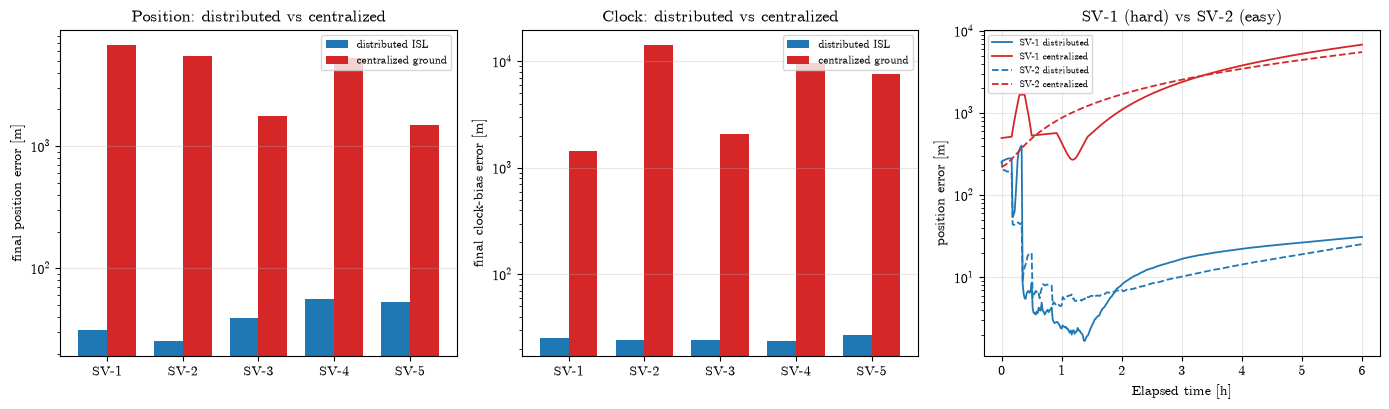

   sat  ISL pos [m] ground pos [m]  ISL clk [m] ground clk [m]
  SV-1         31.0         6789.0         25.5         1454.7
  SV-2         25.4         5506.7         24.3        14370.8
  SV-3         39.0         1751.7         24.3         2066.0
  SV-4         55.7         5255.3         23.7         9762.6
  SV-5         53.0         1502.9         26.8         7634.4

The distributed ISL filter is uniform across the constellation (25-56 m). The centralized ground filter does well on
well-covered satellites but is far worse on the poorly-observed low-perilune SV-1 -- the observability that crosslinks provide, and a ground network alone cannot.


In [10]:
# The centralized filter ran inside `res` (est_central: [N x 8*n_sat], global sat order).
est_c = np.asarray(res.est_central)


def dist_pos_err_ts(r, j):
    return np.linalg.norm(r.truth_states[j][:, :3] - own_block(r, j)[:, :3], axis=1)


def cen_pos_err_ts(r, j):
    return np.linalg.norm(
        r.truth_states[j][:, :3] - est_c[:, 8 * j : 8 * j + 3], axis=1
    )


def cen_clk_err(j):
    return abs(res.truth_states[j][-1, 6] - est_c[-1, 8 * j + 6]) * C_MPS


dist_pos = [final_pos_err(res, j) for j in range(n_sat)]
cen_pos = [
    np.linalg.norm(res.truth_states[j][-1, :3] - est_c[-1, 8 * j : 8 * j + 3])
    for j in range(n_sat)
]
dist_clk = [final_clk_err_m(res, j) for j in range(n_sat)]
cen_clk = [cen_clk_err(j) for j in range(n_sat)]

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
x = np.arange(n_sat)
w = 0.38

# (a) final position error per satellite: distributed vs centralized
axes[0].bar(x - w / 2, dist_pos, w, color="#1F77B4", label="distributed ISL")
axes[0].bar(x + w / 2, cen_pos, w, color="#D62728", label="centralized ground")
axes[0].set_yscale("log")
axes[0].set_xticks(x)
axes[0].set_xticklabels(sat_names)
axes[0].set_ylabel("final position error [m]")
axes[0].set_title("Position: distributed vs centralized")
axes[0].legend(loc="best", fontsize=8)
axes[0].grid(True, axis="y", alpha=0.3)

# (b) final clock-bias error per satellite
axes[1].bar(x - w / 2, dist_clk, w, color="#1F77B4", label="distributed ISL")
axes[1].bar(x + w / 2, cen_clk, w, color="#D62728", label="centralized ground")
axes[1].set_yscale("log")
axes[1].set_xticks(x)
axes[1].set_xticklabels(sat_names)
axes[1].set_ylabel("final clock-bias error [m]")
axes[1].set_title("Clock: distributed vs centralized")
axes[1].legend(loc="best", fontsize=8)
axes[1].grid(True, axis="y", alpha=0.3)

# (c) position-error time series for the hardest (SV-1) and an easy (SV-2) satellite
for j, ls in [(0, "-"), (1, "--")]:
    axes[2].plot(
        t_h,
        dist_pos_err_ts(res, j),
        color="#1F77B4",
        ls=ls,
        lw=1.3,
        label=f"{sat_names[j]} distributed",
    )
    axes[2].plot(
        t_h,
        cen_pos_err_ts(res, j),
        color="#D62728",
        ls=ls,
        lw=1.3,
        label=f"{sat_names[j]} centralized",
    )
axes[2].set_yscale("log")
axes[2].set_xlabel("Elapsed time [h]")
axes[2].set_ylabel("position error [m]")
axes[2].set_title("SV-1 (hard) vs SV-2 (easy)")
axes[2].legend(loc="best", fontsize=7)
axes[2].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(
    f"{'sat':>6}{'ISL pos [m]':>13}{'ground pos [m]':>15}{'ISL clk [m]':>13}{'ground clk [m]':>15}"
)
for j in range(n_sat):
    print(
        f"{sat_names[j]:>6}{dist_pos[j]:13.1f}{cen_pos[j]:15.1f}{dist_clk[j]:13.1f}{cen_clk[j]:15.1f}"
    )
print(
    f"\nThe distributed ISL filter is uniform across the constellation "
    f"({min(dist_pos):.0f}-{max(dist_pos):.0f} m). The centralized ground filter does well on\n"
    f"well-covered satellites but is far worse on the poorly-observed low-perilune {sat_names[0]} "
    f"-- the observability that crosslinks provide, and a ground network alone cannot."
)